✅ Database Ready: 20871 panels.
Phase 2: Generating Large Dataset...

🚀 Starting Smart Training...
Epoch      | Data Loss    | Phys Loss    | Weight
-------------------------------------------------------
10         | 0.008848     | 0.075929     | 0.00
20         | 0.005218     | 0.004785     | 0.00
30         | 0.004737     | 0.003076     | 0.01
40         | 0.003513     | 0.005866     | 0.01
50         | 0.000715     | 0.007945     | 0.01
60         | 0.000312     | 0.000210     | 0.05
70         | 0.000237     | 0.000172     | 0.05
80         | 0.000204     | 0.000155     | 0.05
90         | 0.000175     | 0.000133     | 0.05
100        | 0.000160     | 0.000105     | 0.05
110        | 0.000137     | 0.000091     | 0.05
120        | 0.000108     | 0.000077     | 0.05
130        | 0.000105     | 0.000074     | 0.05
140        | 0.000080     | 0.000064     | 0.05
150        | 0.000069     | 0.000060     | 0.05

Plotting Results...


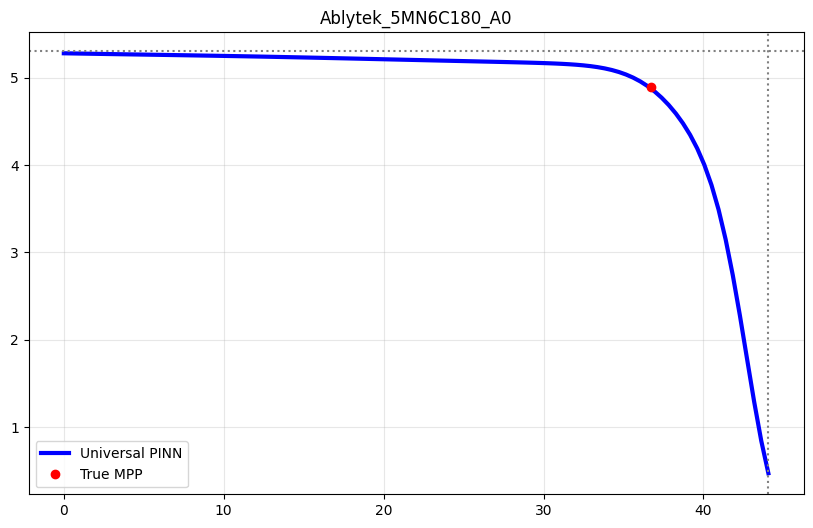

In [20]:
!pip install pvlib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pvlib
from pvlib import pvsystem
from sklearn.preprocessing import RobustScaler

pd.options.mode.chained_assignment = None  

all_modules = pvlib.pvsystem.retrieve_sam('CECMod').T
df_db = all_modules[all_modules['Technology'].str.contains('Si', na=False)].copy()

dna_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref', 'R_s', 'R_sh_ref', 'N_s']
for col in dna_cols + ['V_oc_ref', 'I_sc_ref', 'V_mp_ref', 'I_mp_ref']:
    df_db[col] = pd.to_numeric(df_db[col], errors='coerce')

df_db = df_db[
    (df_db['I_o_ref'] > 1e-15) & (df_db['a_ref'] > 0.5) & 
    (df_db['R_sh_ref'] > 10.0) & (df_db['I_sc_ref'] > 0.5) &
    (df_db['V_oc_ref'] > 10.0)
].dropna(subset=dna_cols)

df_db['I_o_ref_log'] = np.log10(df_db['I_o_ref'])
df_db['R_sh_ref_log'] = np.log10(df_db['R_sh_ref'])

# Scaler
dna_scaler = RobustScaler()
fit_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref_log', 'R_s', 'R_sh_ref_log', 'N_s']
dna_scaler.fit(df_db[fit_cols])

print(f"✅ Database Ready: {len(df_db)} panels.")

# =============================================================================
# 2. DATA GENERATOR (Warning Silenced)
# =============================================================================
def generate_pinn_data(n_panels=2500, pts=50): 
    X, y = [], []
    indices = np.random.choice(len(df_db), n_panels, replace=True)
    
    for idx in indices:
        row = df_db.iloc[idx]
        
        # Wrap in DataFrame to silence sklearn warning
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols) 
        dna_norm = dna_scaler.transform(dna_df)[0]
        
        G = np.random.uniform(200, 1100, pts)
        T_c = np.random.uniform(15, 75, pts)
        
        try:
            IL, Io, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                G, T_c, row['alpha_sc'], row['a_ref'], row['I_L_ref'], 
                row['I_o_ref'], row['R_sh_ref'], row['R_s']
            )
            V_norm_axis = np.linspace(0, 1.0, pts) 
            I_raw = pvsystem.i_from_v(V_norm_axis * row['V_oc_ref'], IL, Io, Rs, Rsh, nNsVth)
            
            for j in range(pts):
                if not np.isnan(I_raw[j]):
                    X.append([
                        G[j]/1000.0, (T_c[j]-25.0)/100.0, V_norm_axis[j]
                    ] + dna_norm.tolist() + [
                        row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0
                    ])
                    y.append(max(0, I_raw[j] / row['I_sc_ref']))
        except Exception: continue
            
    return np.array(X, 'float32'), np.array(y, 'float32').reshape(-1, 1)

print("Phase 2: Generating Large Dataset...")
X_train, y_train = generate_pinn_data(n_panels=2500, pts=40)
# =============================================================================
# 3. ROBUST MODEL (No L2 Reg, Linear Output)
# =============================================================================
model = keras.Sequential([
    layers.InputLayer(shape=(12,)),
    layers.Dense(256, activation='swish'),
    layers.Dense(128, activation='swish'),
    layers.Dense(64, activation='swish'),
    layers.Dense(1, activation='linear') # Linear is crucial for PINNs
])

# Learning Rate Schedule: Start fast, then slow down
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.92,
    staircase=True)

optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

@tf.function
def train_step(x, y_true, phys_weight):
    # persistent=True to allow multiple gradient calculations
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        y_pred = model(x, training=True)

        # --- Physics Check ---
        grads_input = tape.gradient(y_pred, x)
        dI_dV = grads_input[:, 2:3] # Voltage is index 2

        # --- Losses ---
        # 1. Data Loss (MSE)
        loss_data = tf.reduce_mean(tf.square(y_true - y_pred))

        # 2. Physics Loss (Monotonicity + Boundary)
        # Penalize if slope is POSITIVE (wrong)
        loss_monotonic = tf.reduce_mean(tf.square(tf.nn.relu(dI_dV)))

        # 3. Boundary Condition: Current at 0 Voltage should be Isc (y=1.0)
        # We can approximate this by penalizing deviation at low V (if V < 0.05)
        # (Optional, but helps stability)

        # Weighted Sum
        total_loss = loss_data + (phys_weight * loss_monotonic)

    # Calculate Gradients
    grads_weights = tape.gradient(total_loss, model.trainable_variables)
    del tape # Free memory

    optimizer.apply_gradients(zip(grads_weights, model.trainable_variables))
    return loss_data, loss_monotonic

# =============================================================================
# 4. TRAINING LOOP (With "Warmup")
# =============================================================================
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(100000).batch(2048)

print("\n🚀 Starting Smart Training...")
print(f"{'Epoch':<10} | {'Data Loss':<12} | {'Phys Loss':<12} | {'Weight':<6}")
print("-" * 55)

for epoch in range(150):
    # ADAPTIVE WEIGHT:
    # Epoch 0-20:  Weight = 0.00 (Let it find the data first!)
    # Epoch 20-50: Weight = 0.01 (Gently introduce physics)
    # Epoch 50+:   Weight = 0.05 (Enforce strict physics)
    if epoch < 20:
        p_w = 0.0
    elif epoch < 50:
        p_w = 0.01
    else:
        p_w = 0.05

    l_d, l_p = [], []
    for xb, yb in dataset:
        d, p = train_step(xb, yb, tf.constant(p_w, dtype=tf.float32))
        l_d.append(d); l_p.append(p)

    if (epoch+1) % 10 == 0:
        print(f"{epoch+1:<10} | {np.mean(l_d):.6f}     | {np.mean(l_p):.6f}     | {p_w:.2f}")

# =============================================================================
# 5. TEST
# =============================================================================
def test_panel(panel_name):
    try: row = df_db.loc[panel_name]
    except: row = df_db.sample(1).iloc[0]; panel_name = row.name

    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]

    v_sweep = np.linspace(0, 1.0, 100)
    X_test = []
    for v in v_sweep:
        X_test.append([1.0, 0.0, v] + dna_norm.tolist() + [row['V_oc_ref']/50.0, row['I_sc_ref']/10.0])

    y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
    I_pred = y_pred.flatten() * row['I_sc_ref']

    plt.figure(figsize=(10,6))
    plt.plot(v_sweep * row['V_oc_ref'], I_pred, label='Universal PINN', color='blue', lw=3)
    plt.plot(row['V_mp_ref'], row['I_mp_ref'], 'ro', label='True MPP')
    plt.axhline(row['I_sc_ref'], color='gray', ls=':'); plt.axvline(row['V_oc_ref'], color='gray', ls=':')
    plt.title(f"{panel_name}"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print("\nPlotting Results...")
test_panel("Ablytek_5MN6C180_A0")

Starting sampling test.......


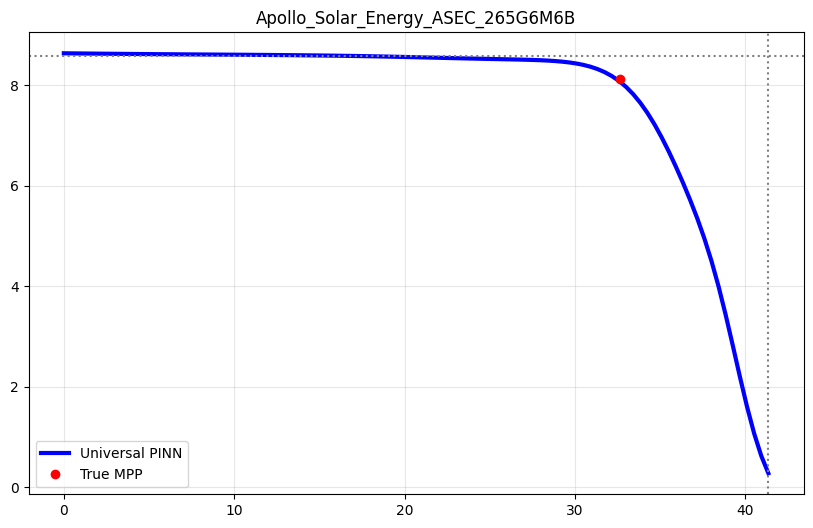

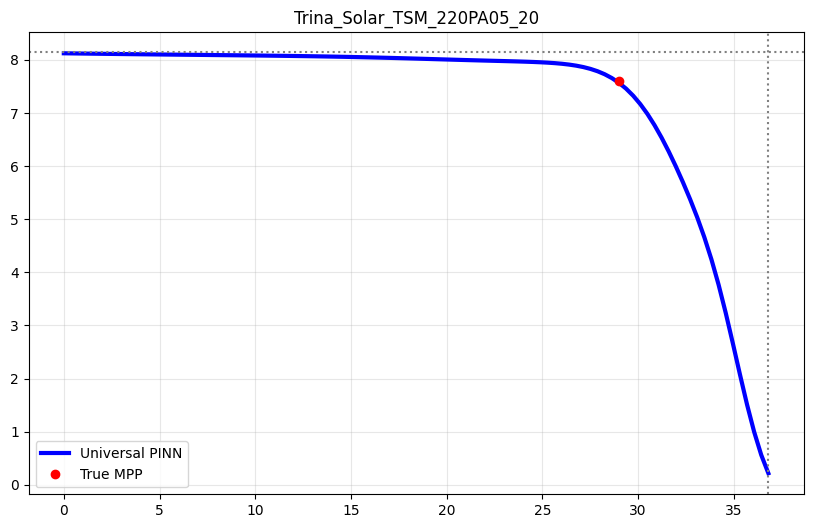

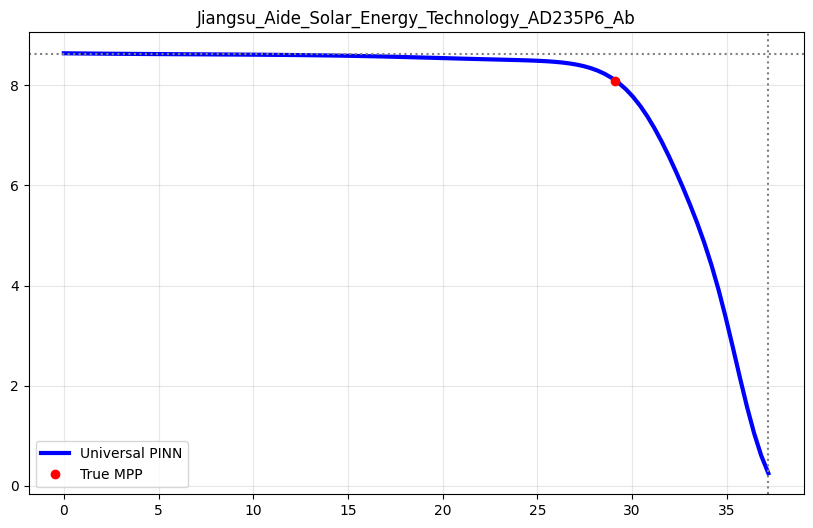

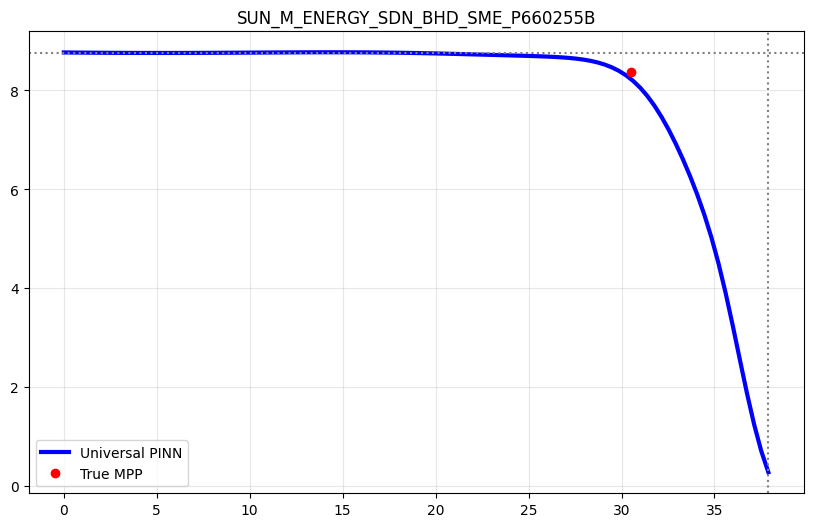

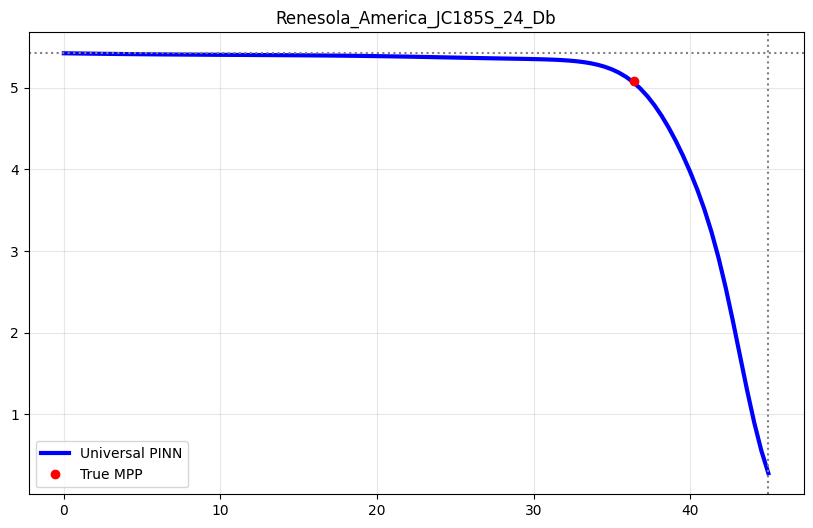

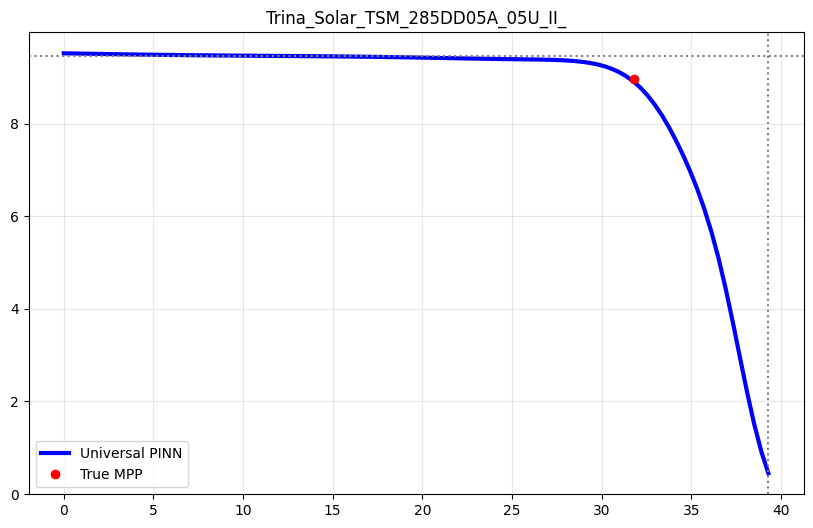

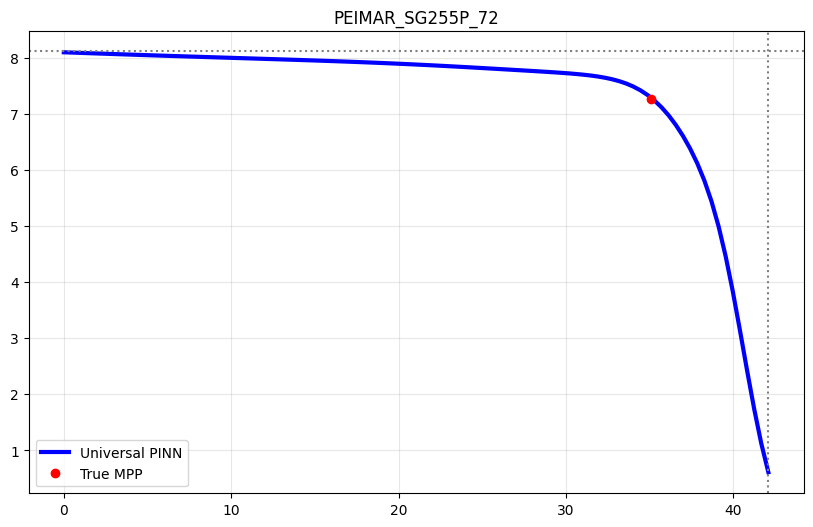

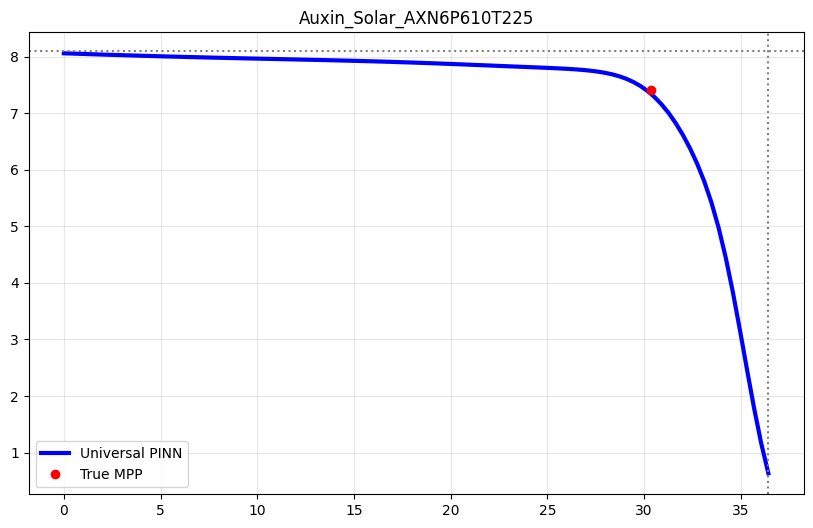

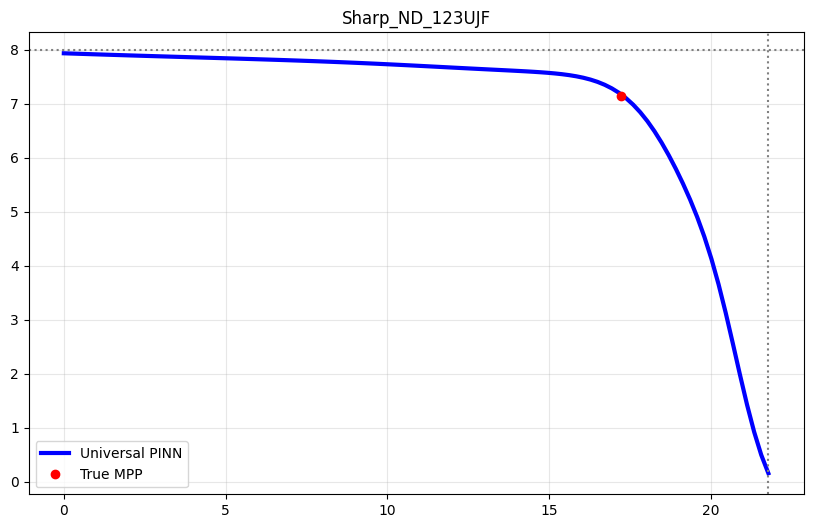

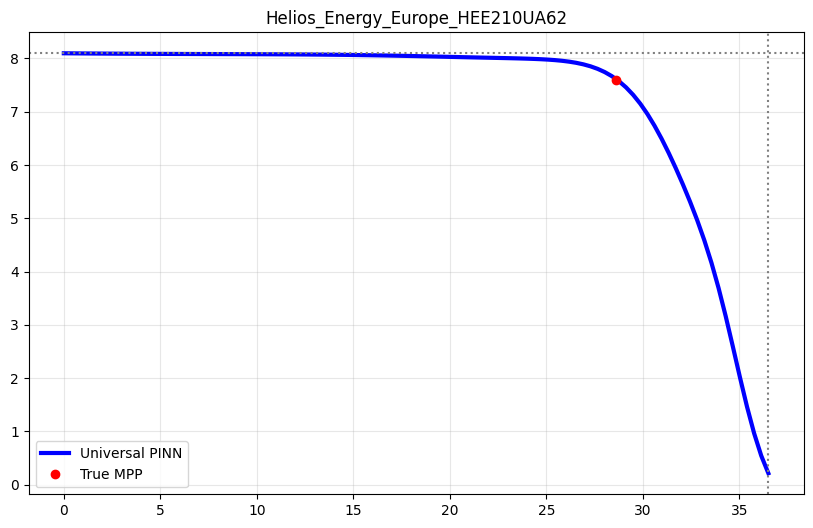

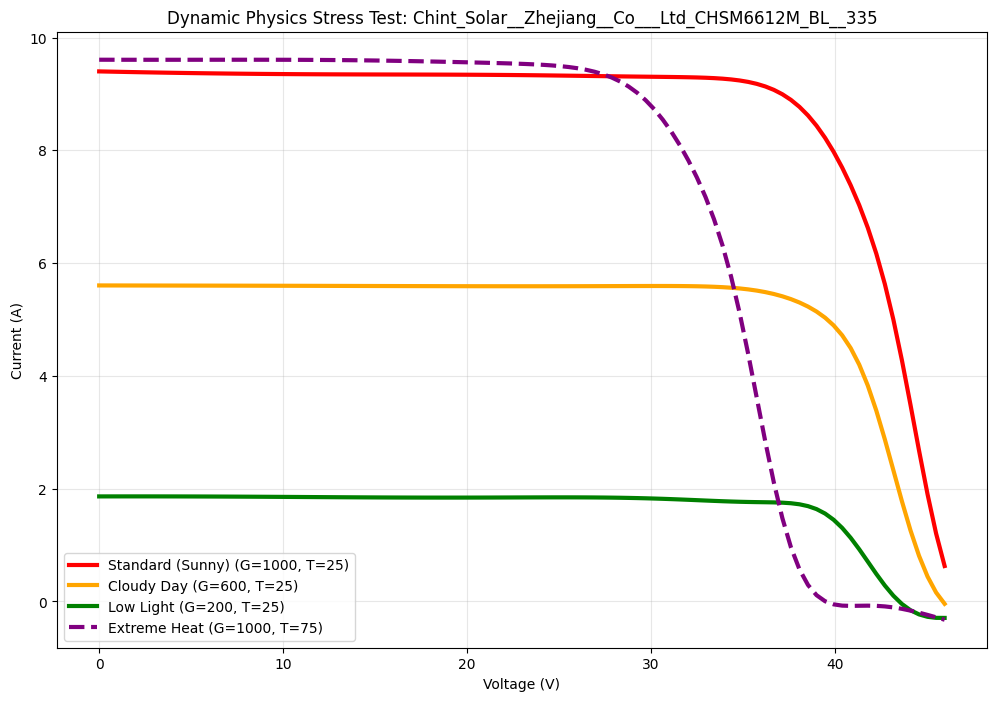

In [4]:
import pvlib
import pandas as pd

# Retrieve the CEC module database
# The result is a pandas DataFrame where module names are the index
cec_modules = pvlib.pvsystem.retrieve_sam('CECMod')

# To see all module names (the index of the DataFrame)
all_module_names = cec_modules.index.tolist()
print("Starting sampling test.......")
for i in range(10):
  test_panel(all_module_names[i])


def stress_test_physics(panel_name):
    try: row = df_db.loc[panel_name]
    except: row = df_db.sample(1).iloc[0]; panel_name = row.name

    # 1. Prepare DNA (Static for this panel)
    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]
    
    # 2. Define 3 Scenarios
    scenarios = [
        {"G": 1000, "T": 25, "Label": "Standard (Sunny)", "Color": "red"},
        {"G": 600,  "T": 25, "Label": "Cloudy Day",       "Color": "orange"},
        {"G": 200,  "T": 25, "Label": "Low Light",        "Color": "green"},
        {"G": 1000, "T": 75, "Label": "Extreme Heat",     "Color": "purple"} # High T should drop Voltage
    ]
    
    plt.figure(figsize=(12, 8))
    
    v_sweep = np.linspace(0, 1.0, 100)
    
    for s in scenarios:
        # Build Inputs: [G_norm, T_norm, V_norm, DNA..., Scalers...]
        X_test = []
        for v in v_sweep:
            X_test.append([
                s["G"]/1000.0,      # G_norm
                (s["T"]-25.0)/100.0,# T_norm
                v                   # Voltage Sweep
            ] + dna_norm.tolist() + [
                row['V_oc_ref']/50.0, 
                row['I_sc_ref']/10.0
            ])
            
        # Predict
        y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
        
        # Denormalize
        I_pred = y_pred.flatten() * row['I_sc_ref']
        V_real = v_sweep * row['V_oc_ref']
        
        # Plot
        style = '--' if s["T"] > 25 else '-'
        plt.plot(V_real, I_pred, label=f"{s['Label']} (G={s['G']}, T={s['T']})", 
                 color=s['Color'], lw=3, linestyle=style)

    plt.title(f"Dynamic Physics Stress Test: {panel_name}")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Test on a random panel
stress_test_physics(df_db.sample(1).index[0])

🚀 STARTING MASSIVE BENCHMARK: 200 PANELS
Simulating full day for 200 panels... (This relies on CPU for Physics)
Processing panel 0/200...
Processing panel 50/200...
Processing panel 100/200...
Processing panel 150/200...


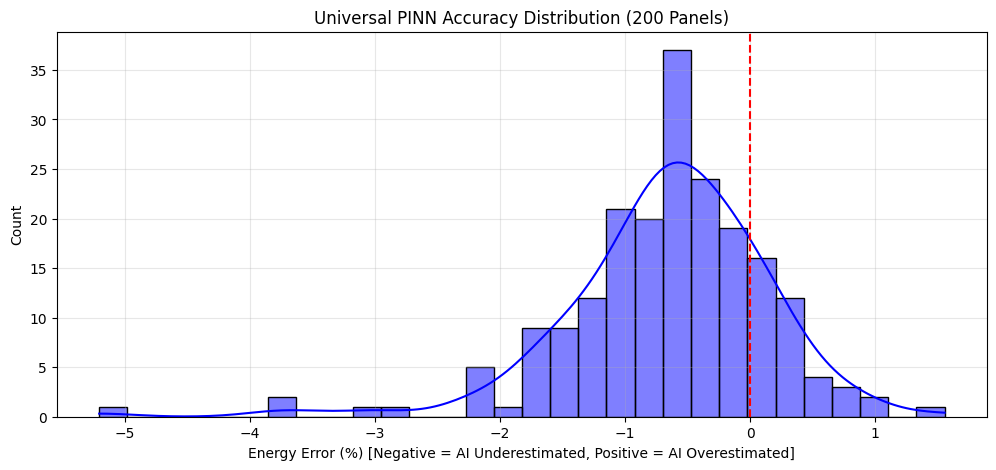

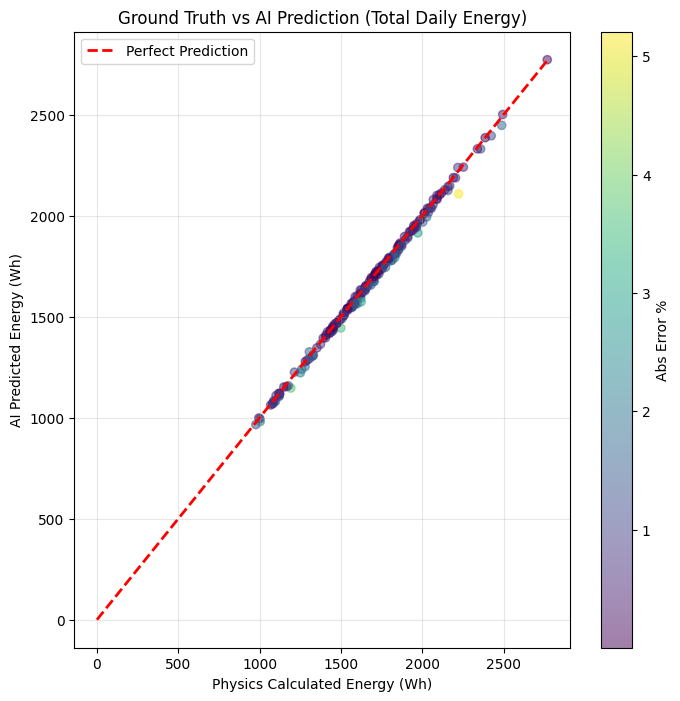


       FINAL SCORECARD       
Panels Tested:      200
Mean Abs Error:     0.79%
Median Abs Error:   0.64%
Standard Dev:       0.83%


In [7]:
!pip install seaborn
import seaborn as sns
def run_massive_benchmark(trained_model, n_panels=500):
    print("="*60)
    print(f"🚀 STARTING MASSIVE BENCHMARK: {n_panels} PANELS")
    print("="*60)
   
    # 1. Select Random Panels
    # We filter for panels with valid parameters first
    test_indices = np.random.choice(len(df_db), n_panels, replace=False)
   
    # 2. Define the "Test Day" Weather (Same for all panels)
    # 12 Hours, 15 min intervals = 48 time steps
    times = pd.date_range('2025-06-21 06:00', '2025-06-21 18:00', freq='15min')
    N_t = len(times)
   
    # Create a nice curve with a "cloud" at noon
    x = np.linspace(0, np.pi, N_t)
    g_signal = 1000 * np.sin(x)
    g_signal[20:26] *= 0.4 # Big cloud at noon
    g_signal[g_signal < 0] = 0
   
    t_signal = 20 + 30 * np.sin(x) # Simple temp curve
   
    # 3. STORAGE FOR RESULTS
    results = []
   
    print(f"Simulating full day for {n_panels} panels... (This relies on CPU for Physics)")
   
    # We have to loop because PVLib (Physics) is not easily vectorized for different panel params
    # But we will batch the AI to show its speed.
   
    for i, idx in enumerate(test_indices):
        if i % 50 == 0: print(f"Processing panel {i}/{n_panels}...")
       
        row = df_db.iloc[idx]
        panel_name = row.name
       
        # --- A. PREPARE DNA ---
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]
       
        # --- B. CALCULATE TRUE ENERGY (PVLIB) ---
        # This is the "slow" part because it solves equations
        energy_true = 0
        try:
            # We calculate params ONCE for the weather vectors (vectorized physics)
            IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                g_signal, t_signal,
                row['alpha_sc'], row['a_ref'], row['I_L_ref'],
                row['I_o_ref'], row['R_sh_ref'], row['R_s']
            )
            # LambertW for max power
            p_mp = pvsystem.singlediode(IL, I0, Rs, Rsh, nNsVth, method='lambertw')['p_mp']
            energy_true = np.sum(np.nan_to_num(p_mp)) * 0.25 # 15 min intervals
        except:
            continue # Skip broken panels
           
        if energy_true < 10: continue # Skip tiny/broken panels
           
        # --- C. CALCULATE AI ENERGY (PINN) ---
        # We perform a Voltage Sweep (0..1) for every timestep
        v_res = 50
        v_sweep = np.linspace(0, 1.0, v_res)
       
        # Build Batch: [Time * Voltage, 12]
        # We stack the weather N times, and sweep voltage N times
        G_flat = np.repeat(g_signal/1000.0, v_res)
        T_flat = np.repeat((t_signal-25.0)/100.0, v_res)
        V_flat = np.tile(v_sweep, N_t)
       
        DNA_flat = np.tile(dna_norm, (len(G_flat), 1))
        SC_flat = np.tile([row['V_oc_ref']/50.0, row['I_sc_ref']/10.0], (len(G_flat), 1))
       
        X_batch = np.column_stack([G_flat, T_flat, V_flat, DNA_flat, SC_flat])
       
        # AI PREDICTION
        y_pred = trained_model.predict(X_batch, batch_size=4096, verbose=0).flatten()
       
        # Denormalize Power
        i_real = y_pred * row['I_sc_ref']
        v_real = V_flat * row['V_oc_ref']
        p_real = v_real * i_real
       
        # Reshape to [Time, Voltage] to find Peak
        p_matrix = p_real.reshape(N_t, v_res)
        ai_p_mp = np.max(p_matrix, axis=1) # Max power at each time step
       
        energy_ai = np.sum(ai_p_mp) * 0.25
       
        # --- D. COMPARE ---
        error_pct = (energy_ai - energy_true) / energy_true * 100
       
        results.append({
            "Name": panel_name,
            "Cells": row['N_s'],
            "True_Wh": energy_true,
            "AI_Wh": energy_ai,
            "Error_%": error_pct
        })

    # 4. VISUALIZATION
    df_res = pd.DataFrame(results)
   
    # Clean up massive outliers (usually caused by bad PVLib data, not AI)
    df_res = df_res[df_res['Error_%'].abs() < 50]
   
    # Plot 1: The Accuracy Histogram
    plt.figure(figsize=(12, 5))
    sns.histplot(df_res['Error_%'], kde=True, color='blue', bins=30)
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Universal PINN Accuracy Distribution ({len(df_res)} Panels)")
    plt.xlabel("Energy Error (%) [Negative = AI Underestimated, Positive = AI Overestimated]")
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # Plot 2: Scatter Correlation
    plt.figure(figsize=(8, 8))
    plt.scatter(df_res['True_Wh'], df_res['AI_Wh'], alpha=0.5, c=df_res['Error_%'].abs(), cmap='viridis')
   
    # Perfect Line
    max_val = max(df_res['True_Wh'].max(), df_res['AI_Wh'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
   
    plt.title("Ground Truth vs AI Prediction (Total Daily Energy)")
    plt.xlabel("Physics Calculated Energy (Wh)")
    plt.ylabel("AI Predicted Energy (Wh)")
    plt.colorbar(label="Abs Error %")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # 5. STATS
    mae = df_res['Error_%'].abs().mean()
    print("\n" + "="*30)
    print("       FINAL SCORECARD       ")
    print("="*30)
    print(f"Panels Tested:      {len(df_res)}")
    print(f"Mean Abs Error:     {mae:.2f}%")
    print(f"Median Abs Error:   {df_res['Error_%'].abs().median():.2f}%")
    print(f"Standard Dev:       {df_res['Error_%'].std():.2f}%")
    print("="*30)
   
    return df_res

# RUN THE MASSIVE TEST
benchmark_data = run_massive_benchmark(model, n_panels=200) # Start with 200 to keep it fast

🚀 STARTING BATCH SIMULATION FOR 10 PANELS

[1/10] Simulating: LG_Electronics_Inc__LG380N2K_A5
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 97.78%


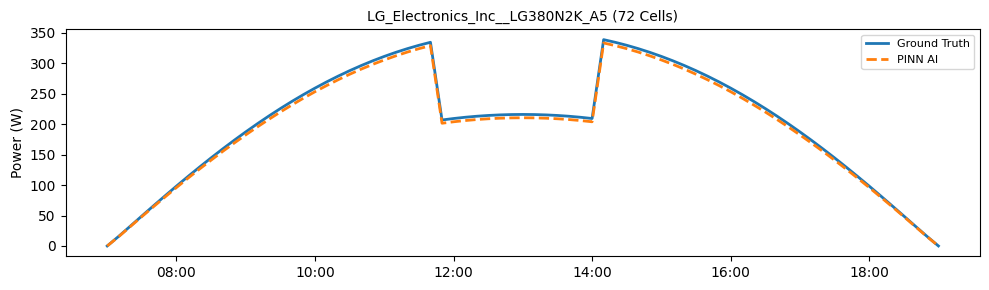


[2/10] Simulating: Shenzhen_Topray_Solar_TPS105S_240W_60_
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.24%


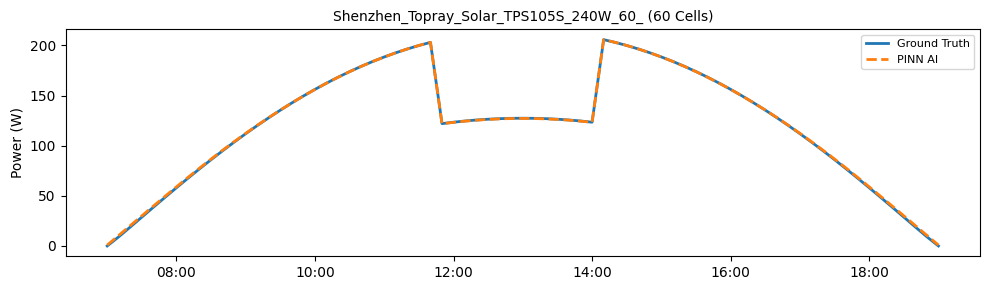


[3/10] Simulating: BYD_Company_Limited_BYD300P6K_36
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.05%


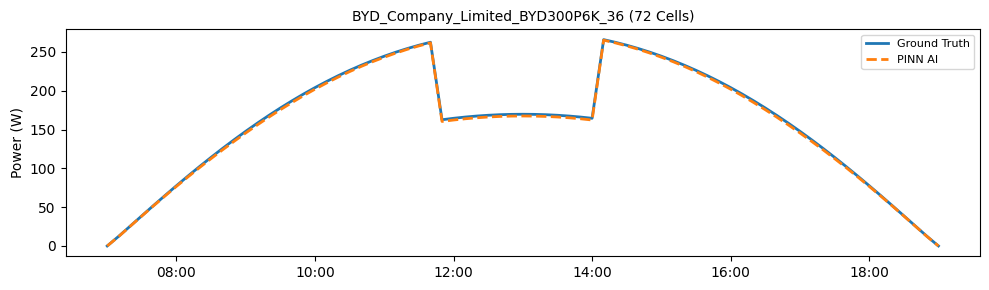


[4/10] Simulating: Kenmec_Mechanical_Engineering_TKSB_20501
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 98.90%


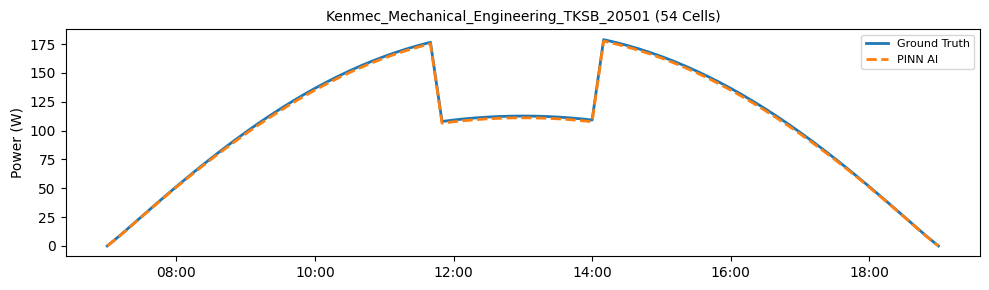


[5/10] Simulating: Topsun_TS_S388TA1
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.69%


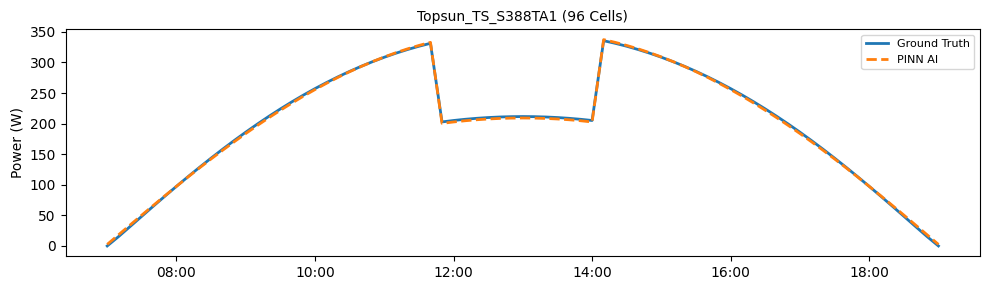


[6/10] Simulating: Westinghouse_Solar_WS_175_1AC3_B_A
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.44%


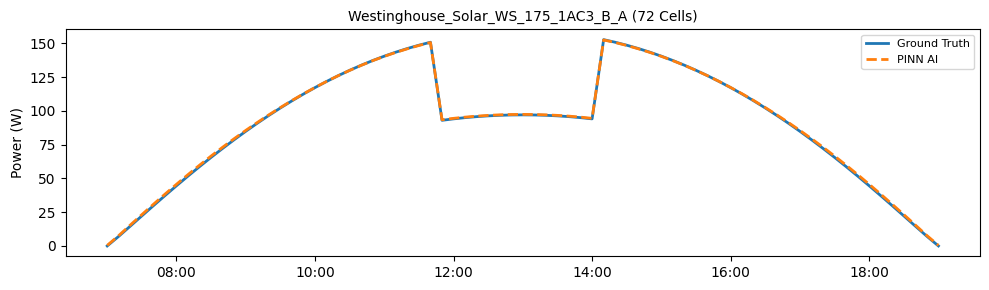


[7/10] Simulating: Symphony_Energy_SE_S228TA
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.34%


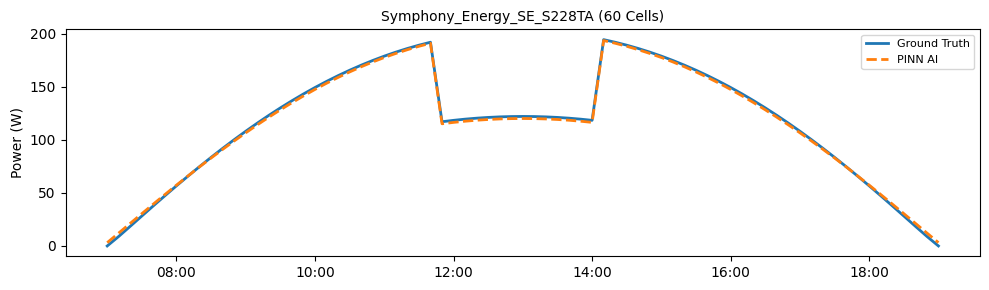


[8/10] Simulating: Itek_Energy_LLC_S59y280
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 98.99%


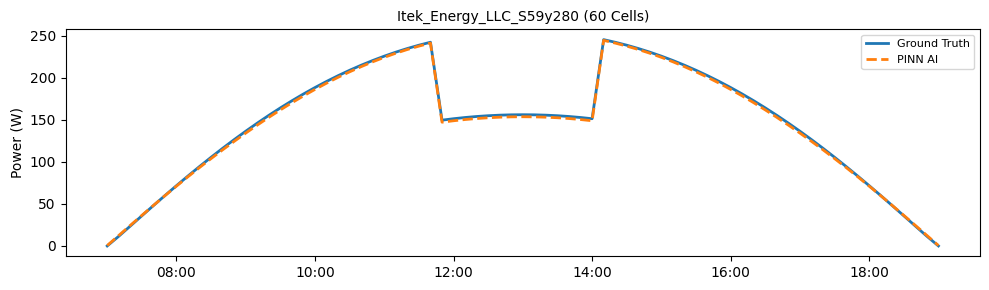


[9/10] Simulating: Nanjing_Daqo_New_Energy_DQ235PSCb
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.11%


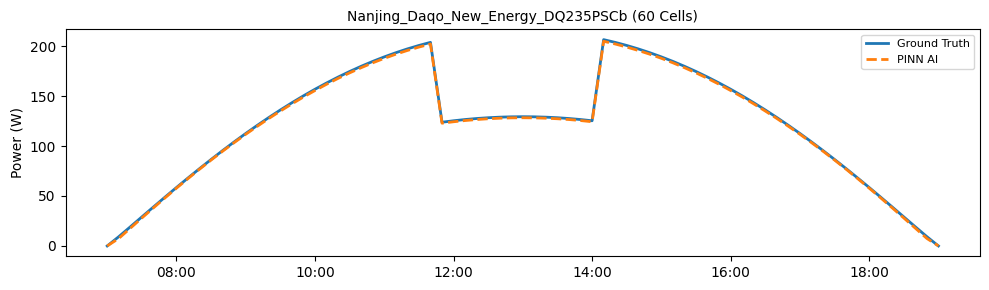


[10/10] Simulating: JA_Solar_JAP6_k__72_305_4BB
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.09%


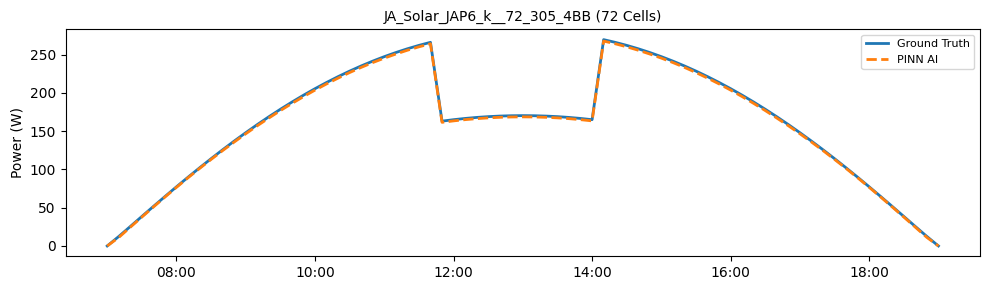

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pvlib
from pvlib import pvsystem
import seaborn as sns

def run_10_panel_simulation(trained_model, df_db, fit_cols, dna_scaler):
    # 1. Select 10 Random Panels
    # We try to get a mix of different cell counts if possible
    random_indices = np.random.choice(len(df_db), 10, replace=False)
    
    print(f"🚀 STARTING BATCH SIMULATION FOR 10 PANELS")
    
    for i, idx in enumerate(random_indices):
        row = df_db.iloc[idx]
        panel_name = row.name
        
        print(f"\n[{i+1}/10] Simulating: {panel_name}")
        print("-" * 60)

        # =====================================================================
        # A. PREPARE DNA
        # =====================================================================
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]

        # =====================================================================
        # B. WEATHER PROFILE (THE "NOTCH")
        # =====================================================================
        times = pd.date_range('2025-07-01 07:00', '2025-07-01 19:00', freq='10min')
        N_t = len(times)

        x = np.linspace(0, np.pi, N_t)
        g_signal = 1000 * np.sin(x)
        
        # Create the visual "Notch" (Cloud)
        start_notch = int(N_t * 0.40)
        end_notch = int(N_t * 0.60)
        g_signal[start_notch:end_notch] *= 0.6
        g_signal = np.clip(g_signal, 0, None)
        
        t_signal = 25 + 20 * np.sin(x)

        # =====================================================================
        # C. AI PREDICTION
        # =====================================================================
        v_res = 100
        v_sweep = np.linspace(0, 1.0, v_res)

        G_flat = np.repeat(g_signal / 1000.0, v_res)
        T_flat = np.repeat((t_signal - 25.0) / 100.0, v_res)
        V_flat = np.tile(v_sweep, N_t)
        DNA_flat = np.tile(dna_norm, (len(G_flat), 1))
        SC_flat = np.tile([row['V_oc_ref']/50.0, row['I_sc_ref']/10.0], (len(G_flat), 1))

        X_batch = np.column_stack([G_flat, T_flat, V_flat, DNA_flat, SC_flat])

        print(f"PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED")
        print(f"Batch predicting {len(X_batch)} points...")

        # Predict
        y_pred = trained_model.predict(X_batch, batch_size=8192, verbose=0).flatten()

        # Denormalize
        i_pred = y_pred * row['I_sc_ref']
        v_real = V_flat * row['V_oc_ref']
        p_pred = v_real * i_pred
        
        # Get Max Power
        p_matrix = p_pred.reshape(N_t, v_res)
        ai_p_mp = np.max(p_matrix, axis=1)

        # =====================================================================
        # D. PHYSICS VERIFICATION
        # =====================================================================
        true_p_mp = []
        
        # Calculate params (Vectorized)
        IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
            g_signal, t_signal, 
            row['alpha_sc'], row['a_ref'], row['I_L_ref'], 
            row['I_o_ref'], row['R_sh_ref'], row['R_s']
        )
        
        # Solve Singlediode (Loop for safety)
        for k in range(N_t):
            if g_signal[k] < 10: 
                true_p_mp.append(0)
                continue
            try:
                res = pvsystem.singlediode(
                    IL[k], I0[k], Rs[k], Rsh[k], nNsVth[k], method='lambertw'
                )
                true_p_mp.append(res['p_mp'])
            except:
                true_p_mp.append(0)

        # Efficiency
        total_ai = np.sum(ai_p_mp)
        total_true = np.sum(true_p_mp)
        eff = (total_ai / total_true) * 100

        print(f"Efficiency: \033[1m{eff:.2f}%\033[0m") 

        # =====================================================================
        # E. PLOTTING
        # =====================================================================
        fig, ax = plt.subplots(figsize=(10, 3))
        
        ax.plot(times, true_p_mp, label='Ground Truth', color='#1f77b4', lw=2)
        ax.plot(times, ai_p_mp, label='PINN AI', color='#ff7f0e', linestyle='--', lw=2)
        
        ax.set_title(f"{panel_name} ({int(row['N_s'])} Cells)", fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.set_ylabel("Power (W)")
        
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

# Run the Batch
run_10_panel_simulation(model, df_db, fit_cols, dna_scaler)